In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
%matplotlib inline

df = pd.read_csv('/content/HR_comma_sep.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nLeft vs Stayed:")
print(df['left'].value_counts())
print("\nCorrelation with left:")

# Only numeric columns for correlation
print(df.select_dtypes(include='number').corr()['left'].sort_values(ascending=False))

Shape: (14999, 10)

Columns: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Department', 'salary']

Left vs Stayed:
left
0    11428
1     3571
Name: count, dtype: int64

Correlation with left:
left                     1.000000
time_spend_company       0.144822
average_montly_hours     0.071287
number_project           0.023787
last_evaluation          0.006567
promotion_last_5years   -0.061788
Work_accident           -0.154622
satisfaction_level      -0.388375
Name: left, dtype: float64


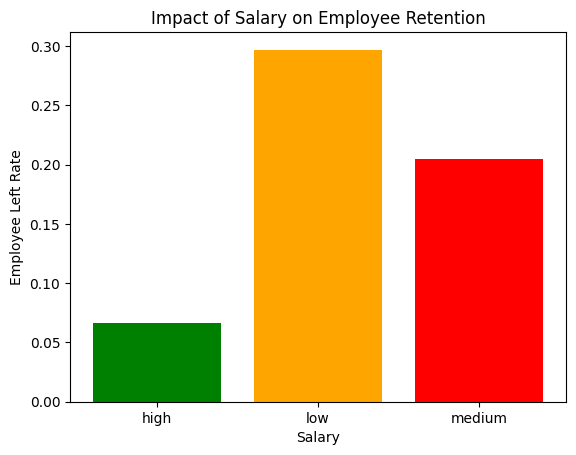

In [5]:
salary_left = df.groupby('salary')['left'].mean()

plt.bar(salary_left.index, salary_left.values,
        color=['green', 'orange', 'red'])
plt.xlabel('Salary')
plt.ylabel('Employee Left Rate')
plt.title('Impact of Salary on Employee Retention')
plt.show()

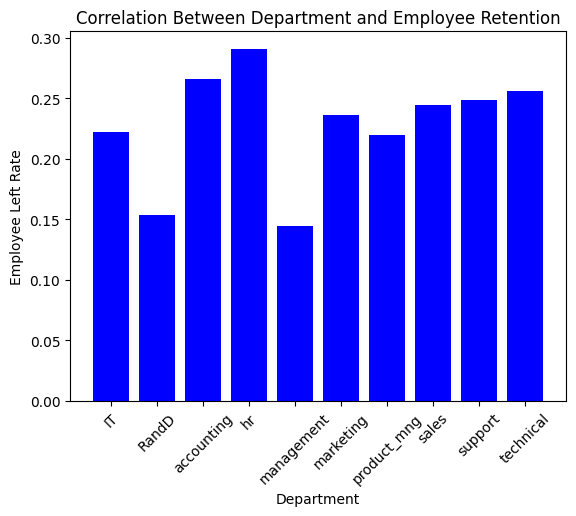

In [6]:
dept_left = df.groupby('Department')['left'].mean()

plt.bar(dept_left.index, dept_left.values, color='blue')
plt.xlabel('Department')
plt.ylabel('Employee Left Rate')
plt.title('Correlation Between Department and Employee Retention')
plt.xticks(rotation=45)
plt.show()

In [7]:
# Variables that impact retention
X = df[['satisfaction_level', 'average_montly_hours',
        'promotion_last_5years', 'number_project',
        'time_spend_company']]

y = df['left']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8
)

# Train
model = LogisticRegression()
model.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


In [8]:
score = model.score(X_test, y_test)
print("Model Accuracy:", round(score * 100, 2), "%")

from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 76.67 %

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86      2283
           1       0.52      0.26      0.35       717

    accuracy                           0.77      3000
   macro avg       0.66      0.59      0.60      3000
weighted avg       0.73      0.77      0.74      3000

